In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("income.csv")
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


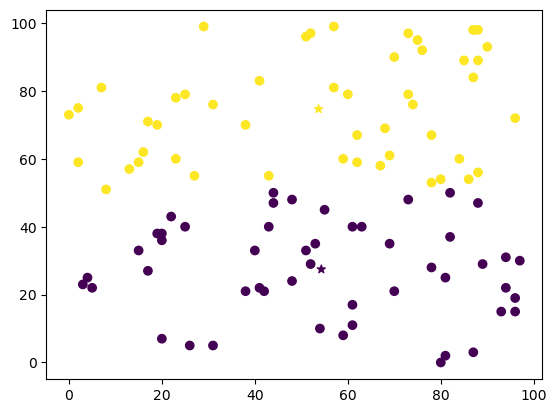

In [14]:
class KMeansClustering():
    def __init__(self,k=3):
        self.k = k
        self.centroids = None
    @staticmethod
    def eucledian_distance(data_point,centroid):
        return np.sqrt(np.sum((centroid - data_point)**2,axis=1))
        
    def fit(self,X,max_iterations=200):#we have just X because we are working on unsupervised learning
        #we generate randomly the centroids but we should put in consideration that the values shouldnt be out of boundaries of the data 
            self.centroids = np.random.uniform(np.amin(X,axis=0),np.amax(X,axis=0),size=(self.k,X.shape[1]))
            for _ in range(max_iterations):
                #creating the labels list 
                y = []
                for data_point in X:
                    #calculate the distances between the data point and all the centroids
                    distances = KMeansClustering.eucledian_distance(data_point,self.centroids)
                    #returns the index of the smallest element 
                    cluster_number = np.argmin(distances)
                    #append the cluster label to y
                    y.append(cluster_number)

                y = np.array(y)

                #we should englobe elements that have the same cluster in a sublist,list of lists 
                clusters_indices = []

                for i in range(self.k):
                    #we create a list containing the indices of data points belonging to each cluster. 
                    #when condition is true it returns the index of the element
                    clusters_indices.append(np.argwhere(y==i))
                clusters_centers = []
                for i,indices in enumerate(clusters_indices):#i is the index and indices is a list of indices
                    if len(indices) == 0:
                        #we set the current centroid as the new one because there is no members
                        clusters_centers.append(self.centroids[i])
                    else :
                        #we did [0] to remove the extra dimension [[2.5, 3.1, 4.0]] became [2.5, 3.1, 4.0]
                        clusters_centers.append(np.mean(X[indices],axis=0)[0])

                if np.max(self.centroids - np.array(clusters_centers)) < 0.0001:
                    break
                else :
                    self.centroids = np.array(clusters_centers)
            return y


random_points = np.random.randint(0,100,(100,2))
Kmeans = KMeansClustering(2)
labels = Kmeans.fit(random_points)
plt.scatter(random_points[:,0],random_points[:,1],c=labels)
plt.scatter(Kmeans.centroids[:,0],Kmeans.centroids[:,1],c=range(len(Kmeans.centroids)),marker='*')

                        
                    
                    
                    
    